In [113]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split,GridSearchCV,KFold
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor,plot_tree
import seaborn as sns
import matplotlib.pyplot as plt

In [95]:
df = pd.read_csv("../data/AI_SocialMedia_Student_Health_Dataset_clean.csv")

In [96]:
df.isnull().any()
# 欠損値はなし。

Student_ID                    False
Age                           False
Gender                        False
Education_Level               False
Daily_Social_Media_Hours      False
Daily_AI_Tool_Usage_Hours     False
Sleep_Hours                   False
Physical_Activity_Hours       False
Mental_Health_Score           False
Physical_Health_Score         False
Social_Isolation_Score        False
Burnout_Level                 False
Academic_Performance_Score    False
Academic_Failure_Risk         False
dtype: bool

In [97]:
df.describe()

,Age,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score,Social_Isolation_Score,Academic_Performance_Score,Academic_Failure_Risk
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,19.040667,4.537500,2.584580,6.544205,1.246332,72.513156,88.019761,4.312027,78.314859,0.060000
std,3.767257,2.398494,1.677988,1.269770,1.038349,9.245482,9.684253,1.162432,11.544651,0.237495
min,13.000000,0.000000,0.000000,2.000000,0.000000,32.560000,48.030000,0.970000,23.990000,0.000000
25%,16.000000,2.830000,1.310000,5.680000,0.310000,66.780000,81.520000,3.470000,70.530000,0.000000
50%,19.000000,4.500000,2.510000,6.550000,1.130000,73.760000,89.470000,4.280000,78.590000,0.000000
75%,22.000000,6.180000,3.740000,7.410000,1.950000,79.580000,97.160000,5.120000,86.700000,0.000000
max,25.000000,14.000000,9.500000,11.150000,5.000000,91.760000,99.980000,8.410000,99.980000,1.000000


In [98]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Education_Level',
       'Daily_Social_Media_Hours', 'Daily_AI_Tool_Usage_Hours', 'Sleep_Hours',
       'Physical_Activity_Hours', 'Mental_Health_Score',
       'Physical_Health_Score', 'Social_Isolation_Score', 'Burnout_Level',
       'Academic_Performance_Score', 'Academic_Failure_Risk'],
      dtype='str')

In [99]:
df.drop(labels=['Student_ID','Education_Level'],inplace=True,axis=1)

In [100]:
categorical_cols = df.select_dtypes(include='object').columns.to_list()
# tmp = mlb.fit_transform(categorical_cols)
# tmp
categorical_cols

/var/folders/dr/zc7jg9wn4g3_yn_nkr7z35300000gn/T/ipykernel_27938/3694860792.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.to_list()


['Gender', 'Burnout_Level']

In [101]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
order = [["Low", "Moderate", "High", "Severe"]]
ordinal_encoder = OrdinalEncoder(categories=order)
df['Burnout_Level'] = ordinal_encoder.fit_transform(df[['Burnout_Level']])


In [102]:
df['Gender'].unique()

<StringArray>
['Male', 'Non-binary', 'Female']
Length: 3, dtype: str

In [103]:
# genderだがLabelEncodingではなくOne-Hotを使用する。LabelEncodingだと数値の大きさによって学習する恐れがあるためである。
onehot_enc = OneHotEncoder(dtype=int)
encoded_data = onehot_enc.fit_transform(df[['Gender']])
onehot_df = pd.DataFrame(data=encoded_data.toarray(),columns=onehot_enc.get_feature_names_out(['Gender']))
onehot_df
df = pd.concat([df, onehot_df], axis=1)
df.drop(labels='Gender',inplace=True,axis=1)

In [104]:
df

,Age,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score,Social_Isolation_Score,Burnout_Level,Academic_Performance_Score,Academic_Failure_Risk,Gender_Female,Gender_Male,Gender_Non-binary
0,19,5.32,1.21,7.30,1.41,74.06,98.90,4.05,0.0,88.80,0,0,1,0
1,16,5.21,3.89,7.81,2.48,76.13,89.94,4.65,1.0,50.60,0,0,0,1
2,25,3.61,2.65,6.34,0.06,65.01,76.75,5.28,0.0,96.67,0,0,1,0
3,23,2.93,1.43,6.12,1.37,74.67,87.38,3.66,0.0,85.65,0,0,1,0
4,20,6.52,1.64,5.23,1.14,67.74,88.04,3.25,1.0,71.84,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,18,6.10,0.72,5.63,0.89,74.08,71.92,3.78,1.0,77.43,0,0,0,1
14996,22,4.55,1.20,7.20,0.00,73.72,85.84,5.06,0.0,75.81,0,1,0,0
14997,13,7.83,1.46,6.22,0.64,70.03,86.62,4.76,1.0,89.84,0,0,1,0
14998,20,6.99,3.00,4.24,1.97,57.38,85.34,2.82,3.0,65.44,1,1,0,0


In [105]:
# ピアソン相関係数可視化。
df.corr(method='pearson')['Mental_Health_Score']

Age                           0.004315
Daily_Social_Media_Hours     -0.399802
Daily_AI_Tool_Usage_Hours    -0.108232
Sleep_Hours                   0.310587
Physical_Activity_Hours       0.245876
Mental_Health_Score           1.000000
Physical_Health_Score         0.243513
Social_Isolation_Score       -0.291725
Burnout_Level                -0.509873
Academic_Performance_Score    0.204037
Academic_Failure_Risk        -0.356007
Gender_Female                 0.002960
Gender_Male                  -0.002149
Gender_Non-binary            -0.002076
Name: Mental_Health_Score, dtype: float64

In [106]:
df.columns
X = df[['Daily_Social_Media_Hours','Daily_AI_Tool_Usage_Hours','Sleep_Hours','Physical_Activity_Hours']]
# X = df.drop(labels='Mental_Health_Score',axis=1)
y = df['Mental_Health_Score']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-1.2 ,-0.45, 1.46, 1.63]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Daily_Social_Media_Hours','Daily_AI_Tool_Usage_Hours','Sleep_Hours', 'Physical_Activity_Hours']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,67.53
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [108]:
# 決定係数R
test_score = model_lr.score(X_test, y_test)
test_score

0.24360445870230663

<Axes: xlabel='Sleep_Hours', ylabel='Mental_Health_Score'>

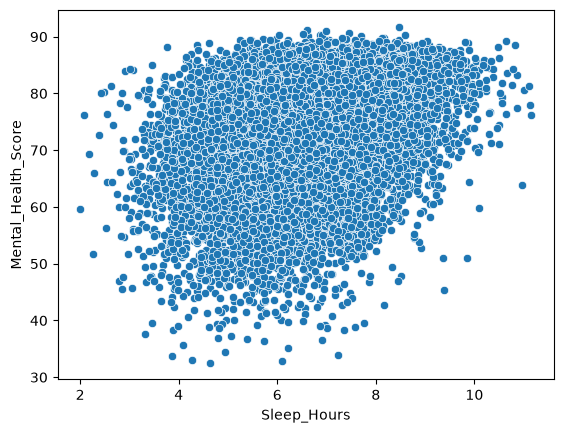

In [109]:
sns.scatterplot(data=df,x='Sleep_Hours',y='Mental_Health_Score')

<Axes: >

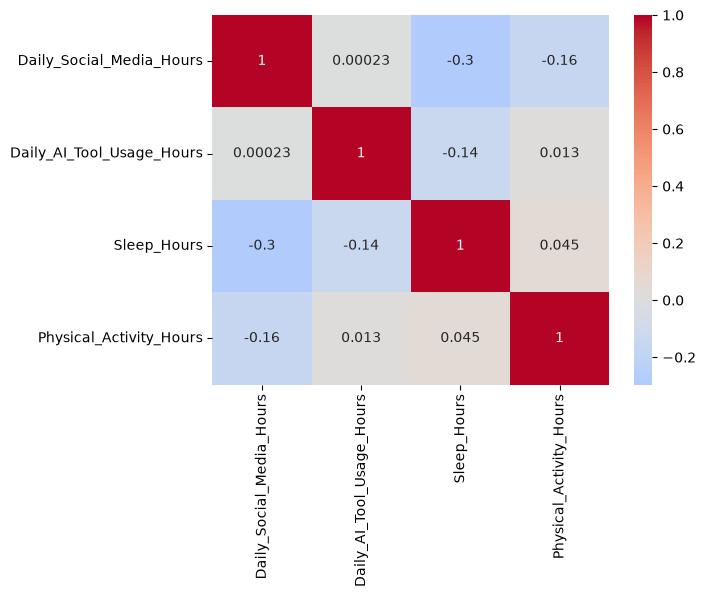

In [110]:
# 多重共線性を確認。
# みた感じ、大きな依存関係はないと判断。z
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', center=0)

In [111]:
from sklearn.tree import DecisionTreeRegressor,plot_tree
from sklearn.model_selection import GridSearchCV,KFold

In [112]:
param = {
    'max_depth': [1,2,3,4,5,6,7,8],
    'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'min_samples_split':[2, 3, 4, 5]
}
# Cross-validationのFolds数は5個とする。
grid_dt = GridSearchCV(estimator=DecisionTreeRegressor(),param_grid=param,cv=5)
grid_dt.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [1, 2, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls t

In [114]:
scores = grid_dt.cv_results_['mean_test_score']
params = grid_dt.cv_results_['params']
for i in range(len(scores)):
    print(f"scores: {scores[i]}, hyper-parameters: {params[i]}")

scores: 0.09815206260125917, hyper-parameters: {'max_depth': 1, 'min_samples_leaf': 1, 'min_samples_split': 2}
scores: 0.09815206260125961, hyper-parameters: {'max_depth': 1, 'min_samples_leaf': 1, 'min_samples_split': 3}
scores: 0.0981520626012592, hyper-parameters: {'max_depth': 1, 'min_samples_leaf': 1, 'min_samples_split': 4}
scores: 0.09815206260125961, hyper-parameters: {'max_depth': 1, 'min_samples_leaf': 1, 'min_samples_split': 5}
scores: 0.09815206260125926, hyper-parameters: {'max_depth': 1, 'min_samples_leaf': 2, 'min_samples_split': 2}
scores: 0.09815206260125953, hyper-parameters: {'max_depth': 1, 'min_samples_leaf': 2, 'min_samples_split': 3}
scores: 0.09815206260125912, hyper-parameters: {'max_depth': 1, 'min_samples_leaf': 2, 'min_samples_split': 4}
scores: 0.09815206260125935, hyper-parameters: {'max_depth': 1, 'min_samples_leaf': 2, 'min_samples_split': 5}
scores: 0.09815206260125948, hyper-parameters: {'max_depth': 1, 'min_samples_leaf': 3, 'min_samples_split': 2}
sc

In [115]:
model_dt = grid_dt.best_estimator_
print(f"最良モデル: {model_dt}")
print(f"訓練スコア(決定係数): {model_dt.score(X_train, y_train)}")
print(f"テストスコア(決定係数): {model_dt.score(X_test, y_test)}")

最良モデル: DecisionTreeRegressor(max_depth=5, min_samples_leaf=6, min_samples_split=3)
訓練スコア(決定係数): 0.23580610901483734
テストスコア(決定係数): 0.1989601180892544
